# Notebook 05 Predictions Export & Diagnostics
Fills the three gaps identified for the paper:
1. Saved `y_true`/`y_prob`/`y_pred` for all four models on the shared test set (`idx_test`) — needed for precision-recall curves and confusion matrices.
2. RF_main feature-importance plot (code existed in `03_baseline_model.ipynb` cell 15 but was never executed/saved).
3. CNN_1D reproduction using the **correct 8→16→32 architecture** (3,953 params — confirmed by parameter count below), matching `04b`/`04c`, run with `augment=False` (i.e. the `CNN_1D_no_augmentation` condition), so this becomes the canonical, reproducible single-split CNN number.

Everything here reuses the exact merge logic, feature sets, split seed (42), and model hyperparameters from `03_baseline_model.ipynb` / `04b_cross_validation.ipynb` / `04c_augmentation_ablation.ipynb` — nothing new is tuned, only diagnostics are added.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, re, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              precision_recall_curve, average_precision_score)
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

DRIVE_ROOT = '/content/drive/MyDrive/SADA'
CSV_PATH   = os.path.join(DRIVE_ROOT, 'balanced_tce.csv')
NPY_DIR    = os.path.join(DRIVE_ROOT, 'processed')
FIG_DIR    = os.path.join(DRIVE_ROOT, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)


Mounted at /content/drive
Device: cuda


## 1. Rebuild the exact same row set + split as Weeks 3/4 (identical test set, n=678)

In [2]:
balanced = pd.read_csv(CSV_PATH)

npy_files = [f for f in os.listdir(NPY_DIR) if f.endswith('.npy') and f != 'failed_kepids.npy']
pattern = re.compile(r'^(\d+)_(\d+)_(PC|FP)\.npy$')
records = []
for fname in npy_files:
    m = pattern.match(fname)
    if not m:
        continue
    kepid, plnt_num, label_str = m.groups()
    records.append({'kepid': int(kepid), 'tce_plnt_num': int(plnt_num),
                     'label': 1 if label_str == 'PC' else 0,
                     'npy_path': os.path.join(NPY_DIR, fname)})
npy_index = pd.DataFrame(records)

data = pd.merge(npy_index, balanced, on=['kepid', 'tce_plnt_num'], how='inner')
data = data.dropna(subset=['tce_period','tce_duration','tce_depth','tce_model_snr']).reset_index(drop=True)
print(f"Row set: {len(data)}")

def flux_shape_features(flux):
    flux = np.asarray(flux, dtype=float)
    n = len(flux)
    mean, std = flux.mean(), flux.std()
    minimum, maximum = flux.min(), flux.max()
    lo, hi = n // 3, 2 * n // 3
    in_transit = flux[lo:hi]
    out_transit = np.concatenate([flux[:lo], flux[hi:]])
    depth_est = out_transit.mean() - in_transit.min()
    in_std = in_transit.std()
    out_std = out_transit.std() if len(out_transit) else 0.0
    if std > 0:
        skew = ((flux - mean) ** 3).mean() / (std ** 3)
        kurt = ((flux - mean) ** 4).mean() / (std ** 4) - 3
    else:
        skew, kurt = 0.0, 0.0
    return {'flux_mean': mean, 'flux_std': std, 'flux_min': minimum, 'flux_max': maximum,
            'flux_depth_est': depth_est, 'flux_in_transit_std': in_std,
            'flux_out_transit_std': out_std, 'flux_skew': skew, 'flux_kurtosis': kurt}

flux_matrix = []
feature_rows = []
for path in data['npy_path']:
    flux = np.load(path).astype(np.float32)
    flux_matrix.append(flux)
    feature_rows.append(flux_shape_features(flux))
flux_matrix = np.stack(flux_matrix)
flux_feats = pd.DataFrame(feature_rows)
data = pd.concat([data.reset_index(drop=True), flux_feats], axis=1)
labels_all = data['label'].values.astype(np.float32)

BLS_FEATURES = ['tce_period', 'tce_duration', 'tce_depth', 'tce_model_snr']
FLUX_FEATURES = ['flux_mean', 'flux_std', 'flux_min', 'flux_max', 'flux_depth_est',
                 'flux_in_transit_std', 'flux_out_transit_std', 'flux_skew', 'flux_kurtosis']
RF_FEATURES = BLS_FEATURES + FLUX_FEATURES
RF_FEATURES_WITH_ROBOVETTER = RF_FEATURES + ['robovetter_score']

y = data['label'].values
idx_train, idx_temp = train_test_split(data.index, test_size=0.30, random_state=SEED, stratify=y)
idx_val, idx_test = train_test_split(idx_temp, test_size=0.50, random_state=SEED, stratify=y[idx_temp])
print(f"Train: {len(idx_train)} | Val: {len(idx_val)} | Test: {len(idx_test)}")

train_df, val_df, test_df = data.loc[idx_train], data.loc[idx_val], data.loc[idx_test]
y_test = test_df['label'].values


Row set: 4515
Train: 3160 | Val: 677 | Test: 678


## 2. BLS_baseline, RF_main, RF_with_robovetter — retrain, save test-set predictions

In [3]:
predictions = {}  # model_name -> dict(y_true, y_prob, y_pred)

def fit_eval_tabular(name, model, feature_cols, scale=False):
    X_train = train_df[feature_cols].values
    X_test  = test_df[feature_cols].values
    y_train = train_df['label'].values
    if scale:
        scaler = StandardScaler().fit(X_train)
        X_train, X_test = scaler.transform(X_train), scaler.transform(X_test)
    model.fit(X_train, y_train)
    probs = model.predict_proba(X_test)[:, 1]
    preds = (probs > 0.5).astype(int)
    predictions[name] = {'y_true': y_test, 'y_prob': probs, 'y_pred': preds}
    print(f"{name}: acc={accuracy_score(y_test, preds):.4f} f1={f1_score(y_test, preds):.4f} auc={roc_auc_score(y_test, probs):.4f}")
    return model

bls_model = fit_eval_tabular('BLS_baseline', LogisticRegression(max_iter=1000), BLS_FEATURES, scale=True)
rf_main   = fit_eval_tabular('RF_main', RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1), RF_FEATURES)
rf_upper  = fit_eval_tabular('RF_with_robovetter', RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1), RF_FEATURES_WITH_ROBOVETTER)


BLS_baseline: acc=0.7021 f1=0.7549 auc=0.7305
RF_main: acc=0.8938 f1=0.8968 auc=0.9505
RF_with_robovetter: acc=0.9956 f1=0.9957 auc=0.9994


## 3. RF_main feature importances — generate + save the plot

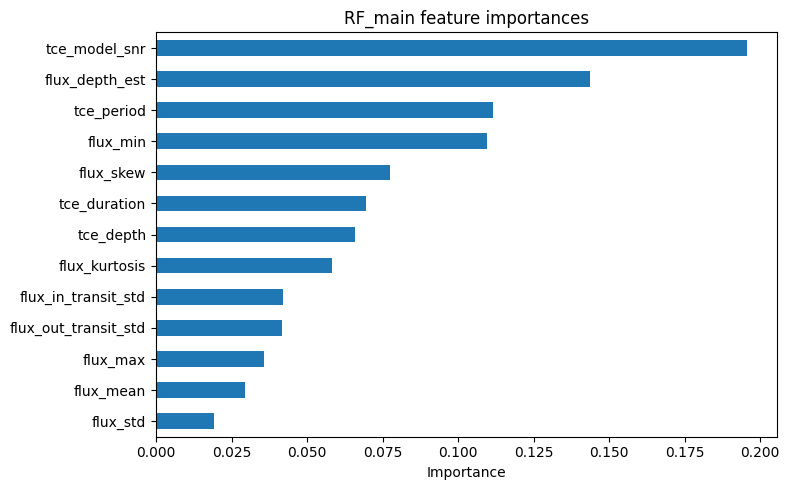

Saved to /content/drive/MyDrive/SADA/figures/rf_main_feature_importance.png


,0
tce_model_snr,0.195584
flux_depth_est,0.143684
tce_period,0.111600
flux_min,0.109591
flux_skew,0.077556
tce_duration,0.069600
tce_depth,0.066027
flux_kurtosis,0.058373
flux_in_transit_std,0.042048
flux_out_transit_std,0.041552


In [4]:
importances = pd.Series(rf_main.feature_importances_, index=RF_FEATURES).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh')
plt.title('RF_main feature importances')
plt.xlabel('Importance')
plt.tight_layout()
fig_path = os.path.join(FIG_DIR, 'rf_main_feature_importance.png')
plt.savefig(fig_path, dpi=150)
plt.show()
print(f"Saved to {fig_path}")
importances.sort_values(ascending=False)


## 4. CNN_1D — correct 8→16→32 architecture, `augment=False` (canonical single-split result)
Identical to `04c_augmentation_ablation.ipynb`'s `Conv1DClassifier` and `train_and_evaluate(augment_train=False)` path — this *is* the `CNN_1D_no_augmentation` run, reproduced here specifically to keep its predictions this time.


In [5]:
class Conv1DClassifier(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        self.block1 = nn.Sequential(nn.Conv1d(1, 8, 5, padding=2), nn.BatchNorm1d(8),
                                     nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(dropout))
        self.block2 = nn.Sequential(nn.Conv1d(8, 16, 5, padding=2), nn.BatchNorm1d(16),
                                     nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(dropout))
        self.block3 = nn.Sequential(nn.Conv1d(16, 32, 5, padding=2), nn.BatchNorm1d(32),
                                     nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(dropout))
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(nn.Linear(32, 16), nn.ReLU(),
                                   nn.Dropout(dropout), nn.Linear(16, 1))

    def forward(self, x):
        x = self.block1(x); x = self.block2(x); x = self.block3(x)
        x = self.gap(x).squeeze(-1)
        return self.head(x).squeeze(-1)

_tmp = Conv1DClassifier()
n_params = sum(p.numel() for p in _tmp.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,} (should be 3,953)")
del _tmp

class FluxDataset(Dataset):
    def __init__(self, indices, augment=False, alpha=0.3):
        self.indices = indices
        self.augment = augment
        self.alpha = alpha
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, i):
        idx = self.indices[i]
        flux = flux_matrix[idx].copy()
        if self.augment:
            noise_std = self.alpha * flux.std()
            flux = flux + np.random.normal(0, noise_std, size=flux.shape).astype(np.float32)
        flux_t = torch.tensor(flux).unsqueeze(0)
        label_t = torch.tensor(labels_all[idx])
        return flux_t, label_t

torch.manual_seed(SEED)  # same reset pattern as 04c, keeps this comparable to that run
model = Conv1DClassifier().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

train_loader = DataLoader(FluxDataset(idx_train, augment=False), batch_size=64, shuffle=True)
val_loader   = DataLoader(FluxDataset(idx_val, augment=False), batch_size=64, shuffle=False)
test_loader  = DataLoader(FluxDataset(idx_test, augment=False), batch_size=64, shuffle=False)

N_EPOCHS, PATIENCE = 60, 8
best_val_loss, best_state, no_improve = float('inf'), None, 0

for epoch in range(N_EPOCHS):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward(); optimizer.step()

    model.eval()
    val_losses = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            val_losses.append(criterion(model(xb), yb).item())
    val_loss = np.mean(val_losses)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

model.load_state_dict(best_state)
model.eval()

all_probs, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        probs = torch.sigmoid(model(xb)).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(yb.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
all_preds = (all_probs > 0.5).astype(int)

predictions['CNN_1D'] = {'y_true': all_labels, 'y_prob': all_probs, 'y_pred': all_preds}
print(f"CNN_1D: acc={accuracy_score(all_labels, all_preds):.4f} f1={f1_score(all_labels, all_preds):.4f} auc={roc_auc_score(all_labels, all_probs):.4f}")
print("(Compare against CNN_1D_no_augmentation in model_results2.csv — should be close, not necessarily identical, due to DataLoader shuffle order)")


Trainable parameters: 3,953 (should be 3,953)
Early stopping at epoch 60
CNN_1D: acc=0.8142 f1=0.8250 auc=0.8864
(Compare against CNN_1D_no_augmentation in model_results2.csv — should be close, not necessarily identical, due to DataLoader shuffle order)


## 5. Save all predictions to Drive (this is the artifact the paper's PR curves / confusion matrices are built from)

In [6]:
rows = []
for model_name, d in predictions.items():
    for yt, yp, ypred in zip(d['y_true'], d['y_prob'], d['y_pred']):
        rows.append({'model': model_name, 'y_true': int(yt), 'y_prob': float(yp), 'y_pred': int(ypred)})

preds_df = pd.DataFrame(rows)
preds_path = os.path.join(DRIVE_ROOT, 'test_predictions.csv')
preds_df.to_csv(preds_path, index=False)
print(f"Saved {len(preds_df)} rows to {preds_path}")
preds_df.head()


Saved 2712 rows to /content/drive/MyDrive/SADA/test_predictions.csv


,model,y_true,y_prob,y_pred
0,BLS_baseline,0,9.607720e-02,0
1,BLS_baseline,1,4.084447e-01,0
2,BLS_baseline,0,6.159606e-01,1
3,BLS_baseline,0,1.407410e-08,0
4,BLS_baseline,1,8.313953e-02,0


## 6. Precision-Recall curves — all four models overlaid

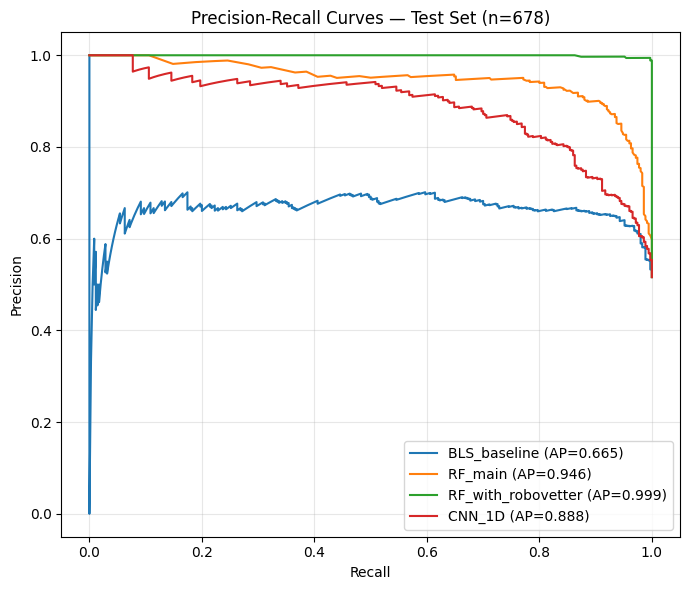

Saved to /content/drive/MyDrive/SADA/figures/pr_curves.png


In [7]:
plt.figure(figsize=(7, 6))
for model_name, d in predictions.items():
    precision, recall, _ = precision_recall_curve(d['y_true'], d['y_prob'])
    ap = average_precision_score(d['y_true'], d['y_prob'])
    plt.plot(recall, precision, label=f"{model_name} (AP={ap:.3f})")

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves — Test Set (n=%d)' % len(y_test))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
fig_path = os.path.join(FIG_DIR, 'pr_curves.png')
plt.savefig(fig_path, dpi=150)
plt.show()
print(f"Saved to {fig_path}")


## 7. Confusion matrices — 2x2 grid, all four models

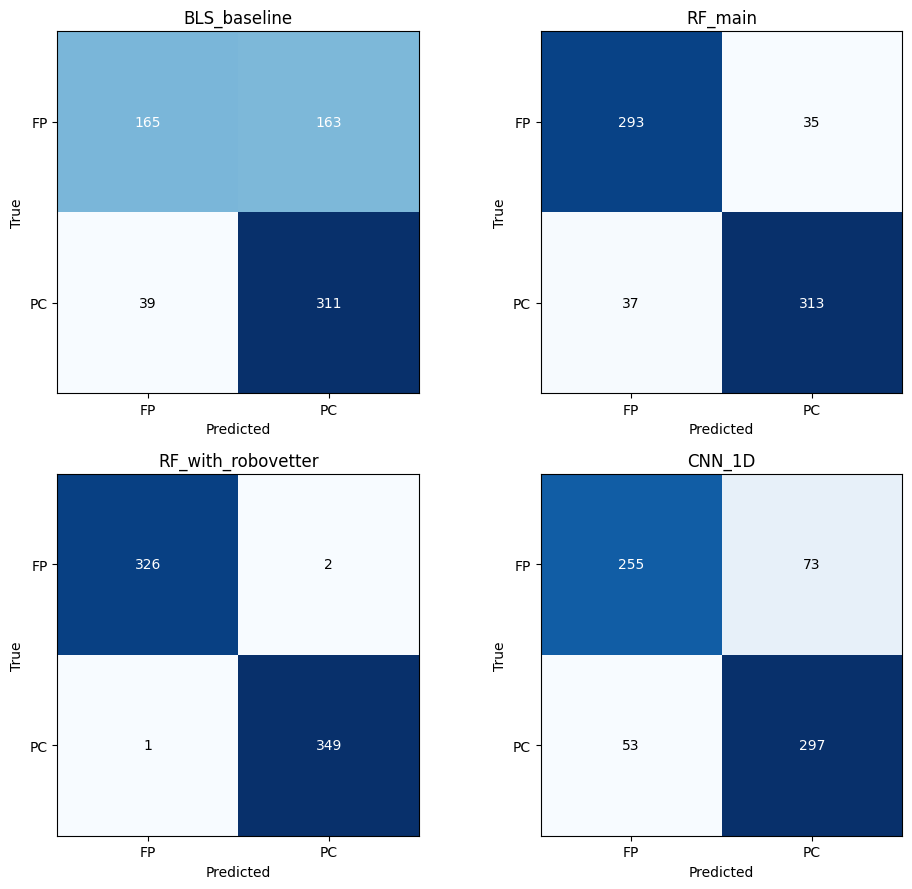

Saved to /content/drive/MyDrive/SADA/figures/confusion_matrices.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
model_order = ['BLS_baseline', 'RF_main', 'RF_with_robovetter', 'CNN_1D']

for ax, model_name in zip(axes.flat, model_order):
    d = predictions[model_name]
    cm = confusion_matrix(d['y_true'], d['y_pred'])
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(model_name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['FP', 'PC'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['FP', 'PC'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                     color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.tight_layout()
fig_path = os.path.join(FIG_DIR, 'confusion_matrices.png')
plt.savefig(fig_path, dpi=150)
plt.show()
print(f"Saved to {fig_path}")
